In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 11

In [3]:
df = pd.read_csv("//content/iss_monthly (1).csv")

df.head()

,month,iss_mean_z,iss_max_z,max_bank,max_bank_td_pct,max_bank_z_score,stress_flag
0,2025-01,1.047448,2.130233,Bank of Baroda,0.28,2.130233,False
1,2025-02,-0.389508,0.251259,HDFC Bank Ltd.,0.06,0.251259,False
2,2025-03,-0.071464,1.733733,State Bank of India,0.90,1.733733,False
3,2025-05,-0.098180,1.909572,HDFC Bank Ltd.,0.12,1.909572,False
4,2025-06,-0.394562,0.804030,HDFC Bank Ltd.,0.08,0.804030,False


In [4]:
df['month'] = pd.to_datetime(df['month'])

df = df.sort_values('month')

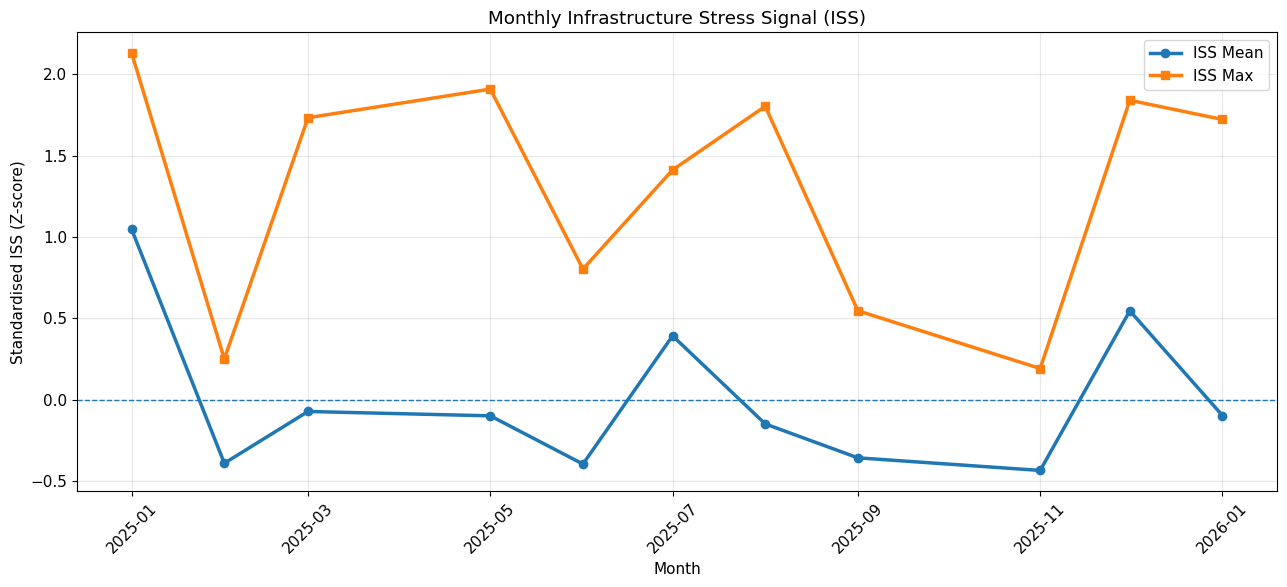

In [5]:
plt.figure(figsize=(13,6))

plt.plot(
    df['month'],
    df['iss_mean_z'],
    marker='o',
    linewidth=2.5,
    label='ISS Mean'
)

plt.plot(
    df['month'],
    df['iss_max_z'],
    marker='s',
    linewidth=2.5,
    label='ISS Max'
)

plt.axhline(0, linestyle='--', linewidth=1)

plt.title("Monthly Infrastructure Stress Signal (ISS)")
plt.xlabel("Month")
plt.ylabel("Standardised ISS (Z-score)")
plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "ISS_Monthly_Trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

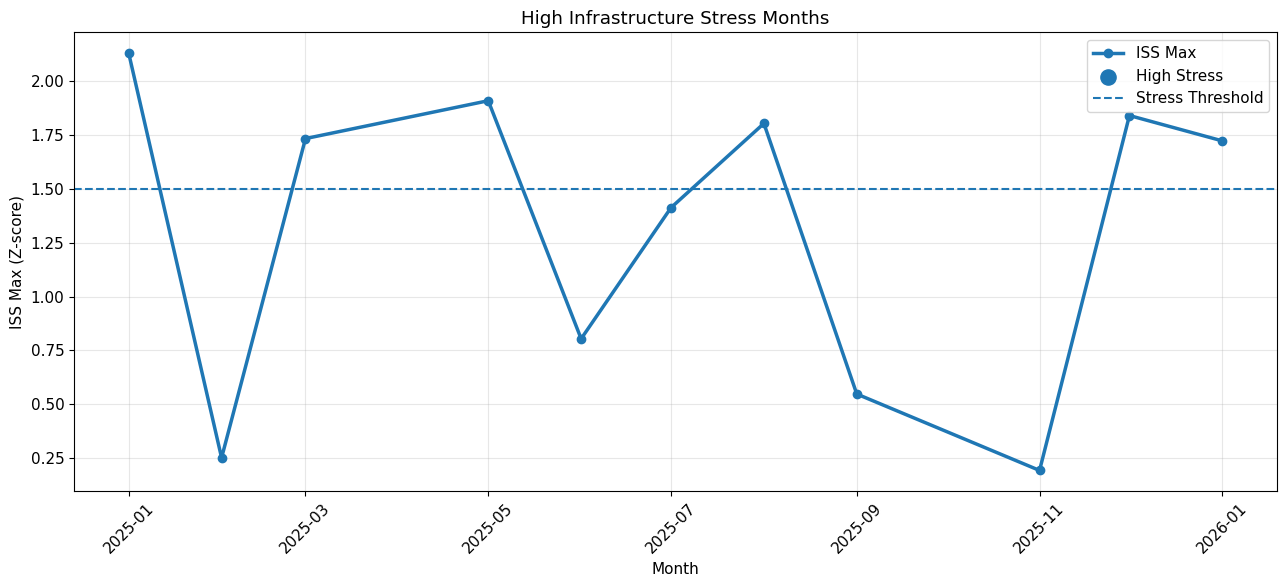

In [6]:
plt.figure(figsize=(13,6))

plt.plot(
    df['month'],
    df['iss_max_z'],
    marker='o',
    linewidth=2.5,
    label='ISS Max'
)

high = df[df["stress_flag"]=="HIGH"]

plt.scatter(
    high["month"],
    high["iss_max_z"],
    s=120,
    label="High Stress"
)

plt.axhline(1.5,
            linestyle="--",
            linewidth=1.5,
            label="Stress Threshold")

plt.title("High Infrastructure Stress Months")
plt.xlabel("Month")
plt.ylabel("ISS Max (Z-score)")

plt.legend()

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "ISS_High_Stress.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
print(df.describe())

                               month    iss_mean_z  iss_max_z  \
count                             11  1.100000e+01  11.000000   
mean   2025-07-01 19:38:10.909090816  8.831320e-18   1.304527   
min              2025-01-01 00:00:00 -4.337658e-01   0.192641   
25%              2025-03-31 12:00:00 -3.729014e-01   0.675762   
50%              2025-07-01 00:00:00 -9.817987e-02   1.723064   
75%              2025-10-01 12:00:00  1.609581e-01   1.822430   
max              2026-01-01 00:00:00  1.047448e+00   2.130233   
std                              NaN  4.711194e-01   0.715918   

       max_bank_td_pct  max_bank_z_score  
count        11.000000         11.000000  
mean          0.402727          1.304527  
min           0.060000          0.192641  
25%           0.170000          0.675762  
50%           0.280000          1.723064  
75%           0.600000          1.822430  
max           0.900000          2.130233  
std           0.288586          0.715918  


In [8]:
plt.savefig("ISS_Monthly_Trends.png", dpi=300, bbox_inches="tight")

<Figure size 1200x600 with 0 Axes>